In [1]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):
    decision = interrupt({
        'type': 'approval',
        'reason': 'Model is about to answer a question',
        'question': state['messages'][-1].content,
        'instructions': "Approve this question? yes/no"
    })

    if decision["approved"] == "no":
        return {'messages': [AIMessage(content= "Not Approved")]}
    else:
        response = llm.invoke(state['messages'])
        return {'messages': [response]}

In [7]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

checkpointer = MemorySaver() # Very Important

app = graph.compile(checkpointer=checkpointer)

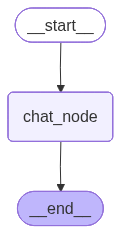

In [8]:
app

In [9]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [10]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f7aa435f-219c-4326-8c54-38d765b54e23')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a question', 'question': 'Explain gradient descent in very simple terms.', 'instructions': 'Approve this question? yes/no'}, id='c9ea3a2d1dfe34a9be0f11a68d7b3a4a')]}

In [11]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a question',
 'question': 'Explain gradient descent in very simple terms.',
 'instructions': 'Approve this question? yes/no'}

In [12]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [13]:
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [14]:
print(final_result["messages"][-1].content)

Sure! Imagine you are standing on a hill and want to get down to the lowest point in the valley. Gradient descent is like taking small steps downhill to reach that lowest spot.

In math or machine learning, this means starting with a guess, then checking which direction will lead you downhill (towards a smaller error or better solution), and then taking a small step that way. You keep repeating this—taking steps down the slope—until you reach the bottom or close enough to it.

So, gradient descent helps find the best answer by slowly walking downhill step by step.
